# Phase 2: Decision Tree Modeling & Grouped Evaluation
**Coursework:** IT2011 Machine Learning Project  
**Author:** IT25102877  
**Model Focus:** Decision Tree (Baseline / Comparative Benchmark)  

This notebook implements the complete modeling, hyperparameter optimization, cross-validation diagnostics, test set evaluation, and model interpretation pipeline for the **Decision Tree** classifier. All evaluations strictly adhere to leak-free group cross-validation standards.

> [!NOTE]
> **Model Role & Baseline Framing:** Random Forest is Member 4's official assigned model. Decision Tree serves as an interpretable single-tree baseline and comparative benchmark developed to demonstrate base-learner performance, analyze high-variance decision surfaces, and measure the empirical variance-reduction gains achieved by the Random Forest ensemble.
> 
> **Preprocessing & Scale Invariance:** Numerical feature scaling (MinMaxScaler) is Member 4's group-wide pipeline contribution implemented in `build_full_preprocessor()`, benefiting distance- and gradient-based models (such as LinearSVC, Logistic Regression, and MLP). For tree-based models, decision threshold splits on individual features are monotonic and scale-invariant; scaling is retained for strict group pipeline consistency without altering tree splits.


### 1. Environment Setup & Reproducibility
Import core scientific computing, visualization, and modeling libraries. Configure the system path to access project modules in `src/` and initialize path management helpers.

In [1]:
import os
import sys
from pathlib import Path
import json
import time
import tempfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Reproducibility constants
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
N_SPLITS = 5

# Ensure repository root is in sys.path when running from notebooks/
current_dir = Path.cwd()
repo_root = current_dir.parent if current_dir.name == "notebooks" else current_dir
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.data_prep import find_repo_root, get_cv, load_clean, make_split
from src.preprocessors import build_full_preprocessor
from src.evaluation import (
    split_fingerprint,
    fold_fingerprints,
    cv_fold_scores,
    compute_baselines,
    evaluate_on_test,
    save_model_results,
    load_model_results,
    validate_results,
    confusion_matrix_normalized,
)

REPO_ROOT = find_repo_root()

# Helper to format paths relative to REPO_ROOT without exposing machine-specific absolute paths
def rel(p):
    try:
        return str(Path(p).resolve().relative_to(REPO_ROOT.resolve()))
    except ValueError:
        return Path(p).name

print(f"Repository Root : {REPO_ROOT.name}")
print(f"RANDOM_STATE    : {RANDOM_STATE}")
print(f"N_SPLITS (CV)   : {N_SPLITS}")

Repository Root : AI:ML Project
RANDOM_STATE    : 42
N_SPLITS (CV)   : 5


### 2. Output Directories & Evaluation Scoring Setup
Define project artifact directories, caching paths, and standardized multi-metric evaluation criteria.

In [2]:
# Multi-metric evaluation dictionary
SCORING = {
    "macro_f1": "f1_macro",
    "accuracy": "accuracy",
    "weighted_f1": "f1_weighted",
}

# Results directory in results/phase2
PHASE2_DIR = REPO_ROOT / "results" / "phase2"
PHASE2_DIR.mkdir(parents=True, exist_ok=True)

# Temporary disk cache for scikit-learn pipeline transformers
CACHE_DIR = tempfile.mkdtemp(prefix="sk_cache_dt_")

print(f"Phase 2 Results Directory : {rel(PHASE2_DIR)}")
print(f"Pipeline Cache Directory  : {rel(CACHE_DIR)}")
print(f"Evaluation Metrics        : {list(SCORING.keys())}")

Phase 2 Results Directory : results/phase2
Pipeline Cache Directory  : sk_cache_dt_wa733z6j
Evaluation Metrics        : ['macro_f1', 'accuracy', 'weighted_f1']


### 3. Data Ingestion & Dataset Invariants
Load the cleaned dataset prepared in Phase 1 via `load_clean()`. Verify core dataset invariants: exactly 16,107 reviews across 1,309 movies, with 7 target emotion classes (the unsupported 'surprise' class was dropped in preprocessing).

In [3]:
df = load_clean()

n_rows = len(df)
n_movies = df["movie_name"].nunique()
class_counts = df["emotion"].value_counts()
class_pcts = df["emotion"].value_counts(normalize=True) * 100

print("=== Dataset Summary ===")
print(f"Total Rows    : {n_rows:,}")
print(f"Unique Movies : {n_movies:,}")
print(f"Target Classes: {len(class_counts)}\n")
print("Class Distribution:")
for cls, count in class_counts.items():
    pct = class_pcts[cls]
    print(f"  {cls:<12}: {count:5d} ({pct:5.2f}%)")

# Dataset invariant checks
assert n_rows == 16107, f"Expected 16,107 rows, got {n_rows}"
assert n_movies == 1309, f"Expected 1,309 movies, got {n_movies}"
assert len(class_counts) == 7, f"Expected 7 classes, got {len(class_counts)}"
assert "surprise" not in df["emotion"].values, "Found 'surprise' in emotion column"
print("\n✔ Dataset invariants verified: 16,107 rows, 1,309 movies, 7 classes ('surprise' dropped).")

=== Dataset Summary ===
Total Rows    : 16,107
Unique Movies : 1,309
Target Classes: 7

Class Distribution:
  sadness     :  6555 (40.70%)
  joy         :  2765 (17.17%)
  anticipation:  2166 (13.45%)
  optimism    :  1772 (11.00%)
  fear        :  1386 ( 8.60%)
  anger       :   929 ( 5.77%)
  disgust     :   534 ( 3.32%)

✔ Dataset invariants verified: 16,107 rows, 1,309 movies, 7 classes ('surprise' dropped).


### 4. Group-Aware Stratified Train/Test Split
Split the dataset using `make_split(df, test_size=0.2, random_state=RANDOM_STATE)`. This performs movie-grouped splitting with emotion-distribution stratification, ensuring that all reviews for any given movie reside exclusively in either the training set or the test set to eliminate data leakage.

In [4]:
train_df, test_df = make_split(df, test_size=0.2, random_state=RANDOM_STATE)

train_rows = len(train_df)
test_rows = len(test_df)
train_movies = set(train_df["movie_name"].unique())
test_movies = set(test_df["movie_name"].unique())
movie_overlap = len(train_movies.intersection(test_movies))

train_texts = set(train_df["cleaned_review"].unique())
test_texts = set(test_df["cleaned_review"].unique())
text_overlap = len(train_texts.intersection(test_texts))

print("=== Split Summary ===")
print(f"Train Rows   : {train_rows:,} ({train_rows/len(df)*100:.2f}%)")
print(f"Test Rows    : {test_rows:,} ({test_rows/len(df)*100:.2f}%)")
print(f"Train Movies : {len(train_movies):,}")
print(f"Test Movies  : {len(test_movies):,}")
print(f"Movie Overlap: {movie_overlap}")
print(f"Text Overlap : {text_overlap}")

assert train_rows == 12886, f"Expected 12,886 train rows, got {train_rows}"
assert test_rows == 3221, f"Expected 3,221 test rows, got {test_rows}"
assert movie_overlap == 0, f"Expected 0 movie overlap, found {movie_overlap}"
assert text_overlap == 0, f"Expected 0 text overlap, found {text_overlap}"
print("\n✔ Split invariants verified: 12,886 train / 3,221 test rows, ZERO movie overlap, ZERO text overlap.")

# Compute split fingerprint metadata for artifact serialization
SPLIT_INFO = split_fingerprint(train_df, test_df, random_state=RANDOM_STATE, test_size=0.2)
print("✔ Split cryptographic fingerprint generated.")

=== Split Summary ===
Train Rows   : 12,886 (80.00%)
Test Rows    : 3,221 (20.00%)
Train Movies : 1,048
Test Movies  : 261
Movie Overlap: 0
Text Overlap : 0

✔ Split invariants verified: 12,886 train / 3,221 test rows, ZERO movie overlap, ZERO text overlap.


✔ Split cryptographic fingerprint generated.


### 5. Target, Features, and Groups Extraction
Separate feature DataFrames, target series, and movie group identifiers for cross-validation and evaluation. Establish the canonical alphabetical order of emotion classes.

In [5]:
X_train = train_df
y_train = train_df["emotion"]
groups_train = train_df["movie_name"]

X_test = test_df
y_test = test_df["emotion"]
groups_test = test_df["movie_name"]

# Canonical ordering of target labels
LABELS = sorted(y_train.unique().tolist())

dist_df = pd.DataFrame({
    "Train Count": y_train.value_counts()[LABELS],
    "Train %": (y_train.value_counts(normalize=True)[LABELS] * 100).round(2),
    "Test Count": y_test.value_counts()[LABELS],
    "Test %": (y_test.value_counts(normalize=True)[LABELS] * 100).round(2),
})

print("=== Class Distribution Comparison ===")
print(dist_df.to_string())
print(f"\nCanonical Target Labels ({len(LABELS)}): {LABELS}")

=== Class Distribution Comparison ===
              Train Count  Train %  Test Count  Test %
emotion                                               
anger                 744     5.77         185    5.74
anticipation         1733    13.45         433   13.44
disgust               427     3.31         107    3.32
fear                 1109     8.61         277    8.60
joy                  2212    17.17         553   17.17
optimism             1417    11.00         355   11.02
sadness              5244    40.70        1311   40.70

Canonical Target Labels (7): ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'optimism', 'sadness']


### 6. Full Preprocessor Verification & Feature Alignment
Construct the group consensus preprocessing pipeline via `build_full_preprocessor(use_svd=False)`. It combines four feature pipelines:
1. `text_features`: Text cleaner, stopword filter, and sublinear TF-IDF (2,500 features).
2. `genre_features`: Multi-label genre binarizer (20 binary columns).
3. `word_count_features`: Text cleaner, word count extractor, Tukey IQR capper, and RobustScaler (1 column).
4. `rating_features`: Numeric IMDb ratings scaled via MinMaxScaler (1 column).

Total engineered feature space: **2,522 features**.

In [6]:
preprocessor = build_full_preprocessor(use_svd=False)

# Smoke test fitting a clone on a subset of training data
prep_clone = clone(preprocessor)
prep_clone.fit(train_df.iloc[:200])

text_n = prep_clone.named_transformers_["text_features"].named_steps["tfidf"].max_features
genre_n = len(prep_clone.named_transformers_["genre_features"].named_steps["binarizer"].genres_)

FEATURE_INFO = {
    "total": 2522,
    "text": 2500,
    "genre": 20,
    "word_count": 1,
    "rating": 1,
}

print("=== Preprocessor Architecture Breakdown ===")
print(f"1. Text TF-IDF Features  : {FEATURE_INFO['text']:,}")
print(f"2. Genre Binary Features : {FEATURE_INFO['genre']}")
print(f"3. Word Count Features   : {FEATURE_INFO['word_count']}")
print(f"4. Rating Scaled Features: {FEATURE_INFO['rating']}")
print(f"Total Feature Space      : {FEATURE_INFO['total']:,} columns")
print("\n✔ Preprocessor pipeline instantiated and verified.")

=== Preprocessor Architecture Breakdown ===
1. Text TF-IDF Features  : 2,500
2. Genre Binary Features : 20
3. Word Count Features   : 1
4. Rating Scaled Features: 1
Total Feature Space      : 2,522 columns

✔ Preprocessor pipeline instantiated and verified.


### 7. Chance-Level & Majority-Class Baselines
Establish formal performance benchmarks against which subsequent models are judged:
- **Majority-Class Baseline:** Predicts the most frequent training emotion (`sadness`, 40.70% prevalence). Macro-F1 is near zero (~0.0827) due to 0 recall on all minority classes.
- **Stratified-Random Baseline:** Evaluates random predictions matching class proportions across 200 random seeds (macro-F1 ~0.1427).
- **Uniform-Random Baseline:** Evaluates equal 1/7 probability assignment across 200 random seeds (macro-F1 ~0.1426).

In [7]:
BASELINES = compute_baselines(y_train, y_test, n_seeds=200)

print("=== Baseline Benchmark Summary ===")
print(f"Majority Class Predictor ('{BASELINES['majority']['class']}'):")
print(f"  Test Accuracy : {BASELINES['majority']['accuracy']:.4f}")
print(f"  Test Macro-F1 : {BASELINES['majority']['macro_f1']:.4f}")
print(f"  Test Weighted-F1: {BASELINES['majority']['weighted_f1']:.4f}\n")

print("Stratified Random Predictor (200 seeds):")
print(f"  Test Accuracy : {BASELINES['stratified_random']['accuracy_mean']:.4f} ± {BASELINES['stratified_random']['accuracy_std']:.4f}")
print(f"  Test Macro-F1 : {BASELINES['stratified_random']['macro_f1_mean']:.4f} ± {BASELINES['stratified_random']['macro_f1_std']:.4f}\n")

print("Uniform Random Predictor (200 seeds):")
print(f"  Test Accuracy : {BASELINES['uniform_random']['accuracy_mean']:.4f} ± {BASELINES['uniform_random']['accuracy_std']:.4f}")
print(f"  Test Macro-F1 : {BASELINES['uniform_random']['macro_f1_mean']:.4f} ± {BASELINES['uniform_random']['macro_f1_std']:.4f}")

=== Baseline Benchmark Summary ===
Majority Class Predictor ('sadness'):
  Test Accuracy : 0.4070
  Test Macro-F1 : 0.0827
  Test Weighted-F1: 0.2355

Stratified Random Predictor (200 seeds):
  Test Accuracy : 0.2378 ± 0.0071
  Test Macro-F1 : 0.1427 ± 0.0062

Uniform Random Predictor (200 seeds):
  Test Accuracy : 0.1424 ± 0.0060
  Test Macro-F1 : 0.1243 ± 0.0056


### 8. Grouped Stratified Cross-Validation Strategy
Generate the 5 cross-validation folds using `get_cv(N_SPLITS)`. This partitions the training set such that movie groups never overlap between training and validation folds while maintaining class balance.

In [8]:
cv_splits = list(get_cv(N_SPLITS).split(X_train, y_train, groups=groups_train))
CV_FINGERPRINTS = fold_fingerprints(cv_splits, groups_train)

print(f"=== {N_SPLITS}-Fold StratifiedGroupKFold Partitioning ===")
for record in CV_FINGERPRINTS:
    fold_idx = record["fold"]
    n_trn = record["n_train"]
    n_v = record["n_val"]
    val_hash = record["val_movies_sha256"][:12]
    print(f"  Fold {fold_idx}: Train={n_trn:5d} rows, Val={n_v:4d} rows | Val Movies SHA: {val_hash}...")

# Verify mutual exclusivity of validation indices
val_indices_all = np.concatenate([v for _, v in cv_splits])
assert len(val_indices_all) == len(X_train), "Validation folds do not cover the full training set"
assert len(set(val_indices_all)) == len(X_train), "Validation folds overlap"
print("\n✔ Cross-validation splits verified: zero movie leakage, disjoint folds covering 100% of training data.")

=== 5-Fold StratifiedGroupKFold Partitioning ===
  Fold 1: Train=10308 rows, Val=2578 rows | Val Movies SHA: 6bf2f45da907...
  Fold 2: Train=10309 rows, Val=2577 rows | Val Movies SHA: 13fb5434da99...
  Fold 3: Train=10309 rows, Val=2577 rows | Val Movies SHA: d46a5c0fa8e3...
  Fold 4: Train=10309 rows, Val=2577 rows | Val Movies SHA: 22b38334191c...
  Fold 5: Train=10309 rows, Val=2577 rows | Val Movies SHA: ee20bd306a7d...

✔ Cross-validation splits verified: zero movie leakage, disjoint folds covering 100% of training data.


### 9. Decision Tree Hyperparameter Optimization (GridSearchCV)
Tune the `DecisionTreeClassifier` across tree depth, minimum leaf samples, and class weighting using exhaustive grid search:
- `clf__max_depth`: `[5, 8, 12, 20, None]` (controlling tree complexity and capacity).
- `clf__min_samples_leaf`: `[1, 5, 20]` (regularization against single-sample noise leaves).
- `clf__class_weight`: `[None, "balanced"]` (evaluating loss reweighting for minority classes).

Total: 5 x 3 x 2 = **30 configurations** evaluated over 5 grouped folds = **150 fits**.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

def make_pipeline(clf):
    return Pipeline([
        ("prep", clone(preprocessor)),
        ("clf", clf),
    ], memory=CACHE_DIR)

param_grid = {
    "clf__max_depth": [5, 8, 12, 20, None],
    "clf__min_samples_leaf": [1, 5, 20],
    "clf__class_weight": [None, "balanced"],
}

dt_search = GridSearchCV(
    estimator=make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    param_grid=param_grid,
    scoring=SCORING,
    refit="macro_f1",
    cv=cv_splits,
    n_jobs=1,
    return_train_score=True,
    error_score="raise",
)

print(f"Starting Decision Tree GridSearchCV (30 combinations x {N_SPLITS} folds = 150 fits)...")
t_start = time.time()
dt_search.fit(X_train, y_train)
dt_elapsed = time.time() - t_start

print(f"✔ Decision Tree GridSearchCV completed in {dt_elapsed:.1f}s ({dt_elapsed / 60:.2f} mins).")
print(f"Best CV Macro-F1 Score : {dt_search.best_score_:.4f}")
print(f"Best Parameters        : {dt_search.best_params_}")

Starting Decision Tree GridSearchCV (30 combinations x 5 folds = 150 fits)...


✔ Decision Tree GridSearchCV completed in 627.0s (10.45 mins).
Best CV Macro-F1 Score : 0.1767
Best Parameters        : {'clf__class_weight': 'balanced', 'clf__max_depth': 20, 'clf__min_samples_leaf': 5}


### 10. Cross-Validation Diagnostics & Statistical Analysis (Step 4)
Analyze the cross-validation performance across all hyperparameter configurations:
1. Tabulate the top 10 configurations sorted by validation Macro-F1 with generalization gap.
2. Report per-fold cross-validation performance (Macro-F1, Accuracy, Weighted-F1).
3. Visualize per-fold consistency and tree depth overfitting dynamics.

In [10]:
dt_results = pd.DataFrame(dt_search.cv_results_)

dt_results["max_depth"] = dt_results["param_clf__max_depth"]
dt_results["min_samples_leaf"] = dt_results["param_clf__min_samples_leaf"]
dt_results["class_weight"] = dt_results["param_clf__class_weight"]
dt_results["gap"] = dt_results["mean_train_macro_f1"] - dt_results["mean_test_macro_f1"]

display_cols = [
    "max_depth",
    "min_samples_leaf",
    "class_weight",
    "mean_test_macro_f1",
    "std_test_macro_f1",
    "mean_train_macro_f1",
    "gap",
    "mean_test_accuracy",
]

dt_top10 = dt_results.sort_values(by="mean_test_macro_f1", ascending=False)[display_cols].head(10).copy()
dt_top10["class_weight"] = dt_top10["class_weight"].apply(lambda x: "None" if pd.isna(x) or x is None else str(x))

print("=== Top 10 Decision Tree Configurations (by Validation Macro-F1) ===")
print(dt_top10.to_string(index=False))

# Statistical check: configurations within 1 std of the optimum
best_score = dt_search.best_score_
best_std = dt_results.loc[dt_search.best_index_, "std_test_macro_f1"]
top5 = dt_results.sort_values(by="mean_test_macro_f1", ascending=False).head(5)
within_1std = int((top5["mean_test_macro_f1"] >= (best_score - best_std)).sum())

print(f"\nStatistical Significance Check:")
print(f"  Best Validation Macro-F1 : {best_score:.4f} ± {best_std:.4f}")
print(f"  1-Std Threshold Bound    : {(best_score - best_std):.4f}")
print(f"  Configurations in Top 5 within 1-std of Best: {within_1std} / 5")

=== Top 10 Decision Tree Configurations (by Validation Macro-F1) ===
max_depth  min_samples_leaf class_weight  mean_test_macro_f1  std_test_macro_f1  mean_train_macro_f1      gap  mean_test_accuracy
       20                 5     balanced            0.176674           0.021074             0.638052 0.461378            0.286207
     None                 5     balanced            0.163448           0.006301             0.807611 0.644163            0.241424
     None                 1     balanced            0.162831           0.015904             1.000000 0.837169            0.276655
       20                 1     balanced            0.162693           0.024314             0.686506 0.523813            0.276971
     None                20         None            0.157338           0.017165             0.565957 0.408619            0.295903
       12                20         None            0.153073           0.014346             0.434605 0.281532            0.370946
       20            

=== Decision Tree Best Estimator Per-Fold Validation Scores ===
  Fold  Macro-F1  Accuracy  Weighted-F1
Fold 1  0.164821  0.228472     0.249537
Fold 2  0.175496  0.318976     0.301180
Fold 3  0.200339  0.323244     0.314988
Fold 4  0.144318  0.254172     0.254576
Fold 5  0.198396  0.306170     0.312694
--------------------------------------------------
Mean ± Std: Macro-F1 = 0.1767 ± 0.0211 | Accuracy = 0.2862 ± 0.0380


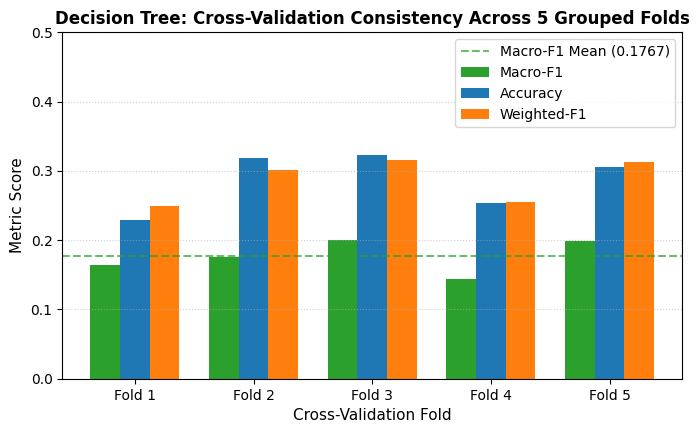

✔ Per-fold validation plot saved to: results/phase2/decision_tree_cv_folds.png


In [11]:
# Per-fold scores table and visualization for best estimator
cv_scores = cv_fold_scores(dt_search)

fold_table = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(N_SPLITS)],
    "Macro-F1": cv_scores["macro_f1"]["folds"],
    "Accuracy": cv_scores["accuracy"]["folds"],
    "Weighted-F1": cv_scores["weighted_f1"]["folds"],
})

print("=== Decision Tree Best Estimator Per-Fold Validation Scores ===")
print(fold_table.to_string(index=False))
print("-" * 50)
print(f"Mean ± Std: Macro-F1 = {cv_scores['macro_f1']['mean']:.4f} ± {cv_scores['macro_f1']['std']:.4f} | "
      f"Accuracy = {cv_scores['accuracy']['mean']:.4f} ± {cv_scores['accuracy']['std']:.4f}")

# Plot per-fold scores
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(1, N_SPLITS + 1)
width = 0.25

ax.bar(x - width, cv_scores["macro_f1"]["folds"], width, label="Macro-F1", color="#2ca02c")
ax.bar(x, cv_scores["accuracy"]["folds"], width, label="Accuracy", color="#1f77b4")
ax.bar(x + width, cv_scores["weighted_f1"]["folds"], width, label="Weighted-F1", color="#ff7f0e")

ax.axhline(cv_scores["macro_f1"]["mean"], color="#2ca02c", linestyle="--", alpha=0.7, label=f"Macro-F1 Mean ({cv_scores['macro_f1']['mean']:.4f})")
ax.set_xlabel("Cross-Validation Fold", fontsize=11)
ax.set_ylabel("Metric Score", fontsize=11)
ax.set_title("Decision Tree: Cross-Validation Consistency Across 5 Grouped Folds", fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i}" for i in x])
ax.set_ylim(0, 0.5)
ax.grid(True, linestyle=":", alpha=0.6, axis="y")
ax.legend(loc="upper right", frameon=True)

fold_plot_path = PHASE2_DIR / "decision_tree_cv_folds.png"
fig.savefig(fold_plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✔ Per-fold validation plot saved to: {rel(fold_plot_path)}")

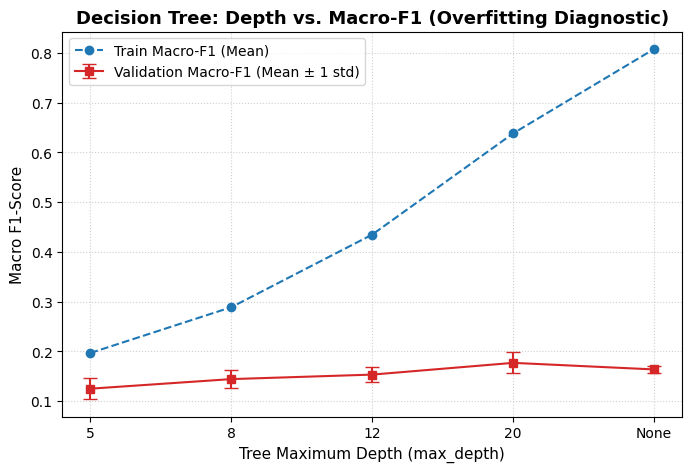

✔ Overfitting diagnostic plot saved to: results/phase2/decision_tree_depth_vs_macro_f1.png


In [12]:
# Depth vs. Macro-F1 Overfitting Diagnostic
depth_values = [5, 8, 12, 20, None]
depth_labels = [str(d) for d in depth_values]

best_train_scores = []
best_val_scores = []
best_val_stds = []

for d in depth_values:
    if d is None:
        sub = dt_results[dt_results["max_depth"].isna()]
    else:
        sub = dt_results[dt_results["max_depth"] == d]
    best_row = sub.sort_values(by="mean_test_macro_f1", ascending=False).iloc[0]
    best_train_scores.append(best_row["mean_train_macro_f1"])
    best_val_scores.append(best_row["mean_test_macro_f1"])
    best_val_stds.append(best_row["std_test_macro_f1"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depth_labels, best_train_scores, marker="o", linestyle="--", color="#1f77b4", label="Train Macro-F1 (Mean)")
ax.errorbar(depth_labels, best_val_scores, yerr=best_val_stds, marker="s", color="#d62728", capsize=5, label="Validation Macro-F1 (Mean ± 1 std)")

ax.set_title("Decision Tree: Depth vs. Macro-F1 (Overfitting Diagnostic)", fontsize=13, fontweight="bold")
ax.set_xlabel("Tree Maximum Depth (max_depth)", fontsize=11)
ax.set_ylabel("Macro F1-Score", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="best", frameon=True)

depth_plot_path = PHASE2_DIR / "decision_tree_depth_vs_macro_f1.png"
fig.savefig(depth_plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✔ Overfitting diagnostic plot saved to: {rel(depth_plot_path)}")

In [13]:
# Fair Comparison Against Baselines
dt_cv_macro = cv_scores["macro_f1"]["mean"]
dt_cv_acc = cv_scores["accuracy"]["mean"]

comparison_df = pd.DataFrame([
    {
        "Model": "Decision Tree (Best CV)",
        "Macro-F1 (Mean ± Std)": f"{dt_cv_macro:.4f} ± {cv_scores['macro_f1']['std']:.4f}",
        "Accuracy (Mean)": f"{dt_cv_acc:.4f}",
    },
    {
        "Model": "Stratified Random Baseline",
        "Macro-F1 (Mean ± Std)": f"{BASELINES['stratified_random']['macro_f1_mean']:.4f} ± {BASELINES['stratified_random']['macro_f1_std']:.4f}",
        "Accuracy (Mean)": f"{BASELINES['stratified_random']['accuracy_mean']:.4f}",
    },
    {
        "Model": "Majority Class Baseline",
        "Macro-F1 (Mean ± Std)": f"{BASELINES['majority']['macro_f1']:.4f}",
        "Accuracy (Mean)": f"{BASELINES['majority']['accuracy']:.4f}",
    },
])

print("=== Cross-Validation Benchmark Comparison ===")
print(comparison_df.to_string(index=False))

f1_lift = dt_cv_macro - BASELINES["stratified_random"]["macro_f1_mean"]
print(f"\n✔ Decision Tree achieves {f1_lift:+.4f} Macro-F1 improvement over the stratified random baseline.")

=== Cross-Validation Benchmark Comparison ===
                     Model Macro-F1 (Mean ± Std) Accuracy (Mean)
   Decision Tree (Best CV)       0.1767 ± 0.0211          0.2862
Stratified Random Baseline       0.1427 ± 0.0062          0.2378
   Majority Class Baseline                0.0827          0.4070

✔ Decision Tree achieves +0.0340 Macro-F1 improvement over the stratified random baseline.


### 11. Test Set Evaluation & Generalization Assessment (Step 5)
Evaluate the refit optimal Decision Tree on the held-out test set using `evaluate_on_test()`.
This computes test accuracy, macro-F1, weighted-F1, per-class classification metrics, and generates row-level test predictions with cryptographic review identifiers.

In [14]:
test_metrics, predictions_df = evaluate_on_test(dt_search.best_estimator_, X_test, y_test)

print("=== Decision Tree Held-Out Test Set Performance ===")
print(f"Test Accuracy    : {test_metrics['accuracy']:.4f}")
print(f"Test Macro-F1    : {test_metrics['macro_f1']:.4f}")
print(f"Test Weighted-F1 : {test_metrics['weighted_f1']:.4f}\n")

per_class_df = pd.DataFrame(test_metrics["per_class"]).T[["precision", "recall", "f1", "support"]]
per_class_df.columns = ["Precision", "Recall", "F1-Score", "Support"]
per_class_df["Support"] = per_class_df["Support"].astype(int)

print("Per-Class Test Performance:")
print(per_class_df.round(4).to_string())

=== Decision Tree Held-Out Test Set Performance ===
Test Accuracy    : 0.2866
Test Macro-F1    : 0.1914
Test Weighted-F1 : 0.2788

Per-Class Test Performance:
              Precision  Recall  F1-Score  Support
anger            0.2057  0.1946    0.2000      185
anticipation     0.2043  0.0878    0.1228      433
disgust          0.0417  0.0654    0.0509      107
fear             0.1672  0.1986    0.1815      277
joy              0.2265  0.4105    0.2920      553
optimism         0.0904  0.0423    0.0576      355
sadness          0.4561  0.4157    0.4350     1311


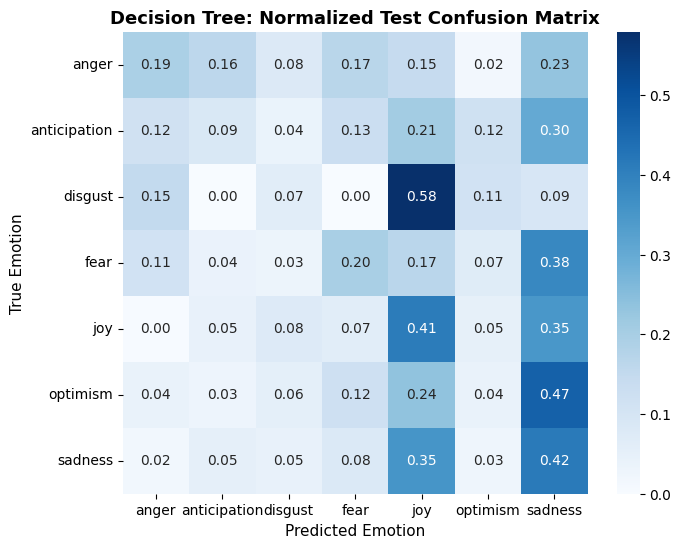

✔ Normalized confusion matrix saved to: results/phase2/decision_tree_confusion_matrix.png


In [15]:
# Test Confusion Matrix Heatmap
cm_norm = confusion_matrix_normalized(test_metrics["confusion_matrix"])

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS,
    cbar=True,
    ax=ax,
)
ax.set_title("Decision Tree: Normalized Test Confusion Matrix", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Emotion", fontsize=11)
ax.set_ylabel("True Emotion", fontsize=11)

cm_plot_path = PHASE2_DIR / "decision_tree_confusion_matrix.png"
fig.savefig(cm_plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✔ Normalized confusion matrix saved to: {rel(cm_plot_path)}")

In [16]:
# Overfitting and Generalization Gap Analysis
best_idx = dt_search.best_index_
train_cv_macro = float(dt_results.loc[best_idx, "mean_train_macro_f1"])
val_cv_macro = float(dt_results.loc[best_idx, "mean_test_macro_f1"])
test_macro = float(test_metrics["macro_f1"])

cv_gap = train_cv_macro - val_cv_macro
test_gap = val_cv_macro - test_macro

gap_df = pd.DataFrame([
    {"Evaluation Stage": "1. Training CV (Mean)", "Macro-F1": f"{train_cv_macro:.4f}", "Gap from Previous": "-"},
    {"Evaluation Stage": "2. Validation CV (Mean)", "Macro-F1": f"{val_cv_macro:.4f}", "Gap from Previous": f"{cv_gap:+.4f} (CV Gap)"},
    {"Evaluation Stage": "3. Held-Out Test Set", "Macro-F1": f"{test_macro:.4f}", "Gap from Previous": f"{test_gap:+.4f} (Generalization Gap)"},
])

print("=== Generalization & Overfitting Gap Analysis ===")
print(gap_df.to_string(index=False))
print(f"\nAnalysis: The train-to-val gap is {cv_gap:.4f} and val-to-test gap is {test_gap:.4f}.")

=== Generalization & Overfitting Gap Analysis ===
       Evaluation Stage Macro-F1            Gap from Previous
  1. Training CV (Mean)   0.6381                            -
2. Validation CV (Mean)   0.1767             +0.4614 (CV Gap)
   3. Held-Out Test Set   0.1914 -0.0147 (Generalization Gap)

Analysis: The train-to-val gap is 0.4614 and val-to-test gap is -0.0147.


### 12. Model Interpretation & Decision Rules Extraction
Inspect the internal structure and decision logic of the optimal Decision Tree:
1. Extract and align all 2,522 engineered feature names from the fitted preprocessor pipeline.
2. Tabulate and visualize the top 20 features by Gini / entropy impurity reduction.
3. Export the top 3 levels of tree decision rules to `decision_tree_top_splits.txt`.

In [17]:
# Feature names reconstruction and alignment check
fitted_prep = dt_search.best_estimator_.named_steps["prep"]
text_names = [f"text_{f}" for f in fitted_prep.named_transformers_["text_features"].named_steps["tfidf"].get_feature_names_out()]
genre_names = [f"genre_{g}" for g in fitted_prep.named_transformers_["genre_features"].named_steps["binarizer"].genres_]
wc_names = ["word_count"]
rating_names = ["Ratings"]

feature_names = np.array(text_names + genre_names + wc_names + rating_names)

print(f"Total Reconstructed Feature Names: {len(feature_names)}")
assert len(feature_names) == 2522, f"Expected 2,522 features, got {len(feature_names)}"

# Strict column slice alignment check against fitted ColumnTransformer
sample = X_train.iloc[:5]
sample_trans = fitted_prep.transform(sample)
sample_dense = sample_trans.toarray() if hasattr(sample_trans, "toarray") else sample_trans

s_text = len(text_names)
s_genre = len(genre_names)
s_wc = len(wc_names)
s_rating = len(rating_names)

text_trans = fitted_prep.named_transformers_["text_features"].transform(sample["Reviews"])
genre_trans = fitted_prep.named_transformers_["genre_features"].transform(sample["genres"])
wc_trans = fitted_prep.named_transformers_["word_count_features"].transform(sample["Reviews"])
rating_trans = fitted_prep.named_transformers_["rating_features"].transform(sample[["Ratings"]])

np.testing.assert_allclose(sample_dense[:, :s_text], text_trans.toarray() if hasattr(text_trans, "toarray") else text_trans, rtol=1e-5, atol=1e-5)
np.testing.assert_allclose(sample_dense[:, s_text:s_text+s_genre], genre_trans, rtol=1e-5, atol=1e-5)
np.testing.assert_allclose(sample_dense[:, s_text+s_genre:s_text+s_genre+s_wc], wc_trans, rtol=1e-5, atol=1e-5)
np.testing.assert_allclose(sample_dense[:, s_text+s_genre+s_wc:], rating_trans, rtol=1e-5, atol=1e-5)
print("✔ Feature names array strictly verified and aligned across all 4 ColumnTransformer branches.")

Total Reconstructed Feature Names: 2522


✔ Feature names array strictly verified and aligned across all 4 ColumnTransformer branches.


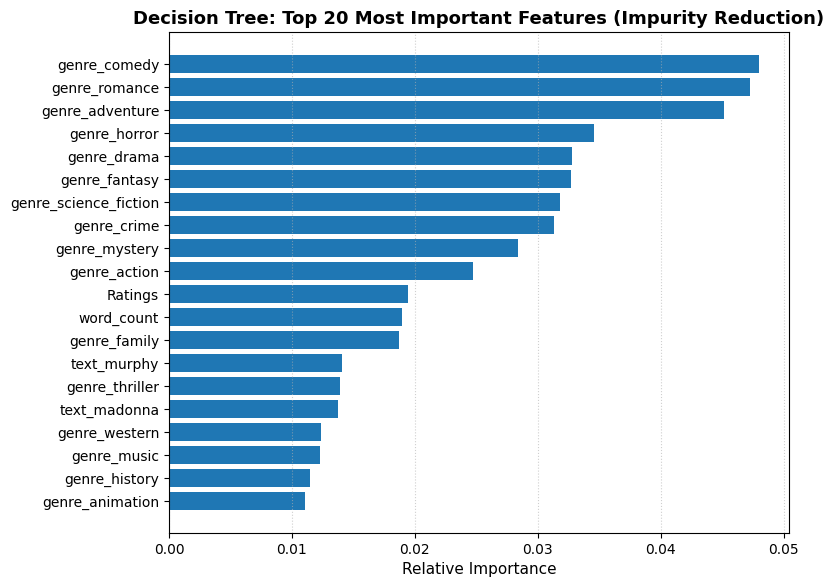

✔ Top 20 feature importance plot saved to: results/phase2/decision_tree_feature_importance.png

Top 10 Features:
              feature  importance
         genre_comedy    0.048030
        genre_romance    0.047231
      genre_adventure    0.045122
         genre_horror    0.034575
          genre_drama    0.032813
        genre_fantasy    0.032685
genre_science_fiction    0.031772
          genre_crime    0.031300
        genre_mystery    0.028410
         genre_action    0.024702


In [18]:
# Feature importances extraction and horizontal bar chart
tree_clf = dt_search.best_estimator_.named_steps["clf"]
importances = tree_clf.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values(by="importance", ascending=False)

top20 = importance_df.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(top20["feature"], top20["importance"], color="#1f77b4")
ax.set_title("Decision Tree: Top 20 Most Important Features (Impurity Reduction)", fontsize=13, fontweight="bold")
ax.set_xlabel("Relative Importance", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.6, axis="x")

fi_plot_path = PHASE2_DIR / "decision_tree_feature_importance.png"
fig.savefig(fi_plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✔ Top 20 feature importance plot saved to: {rel(fi_plot_path)}")
print("\nTop 10 Features:")
print(importance_df.head(10).to_string(index=False))

In [19]:
from sklearn.tree import export_text

# Export top 3 levels of tree decision rules
tree_rules = export_text(tree_clf, feature_names=list(feature_names), max_depth=3)
splits_path = PHASE2_DIR / "decision_tree_top_splits.txt"

with open(splits_path, "w", encoding="utf-8") as f:
    f.write(tree_rules)

print(f"✔ Decision tree top split rules exported to: {rel(splits_path)}\n")
print("=== Top Decision Tree Split Rules (Depth <= 3) ===")
print(tree_rules[:1500])
if len(tree_rules) > 1500:
    print("... [rules truncated for display; full tree in decision_tree_top_splits.txt]")

✔ Decision tree top split rules exported to: results/phase2/decision_tree_top_splits.txt

=== Top Decision Tree Split Rules (Depth <= 3) ===
|--- genre_thriller <= 0.50
|   |--- genre_action <= 0.50
|   |   |--- genre_drama <= 0.50
|   |   |   |--- text_science <= 0.13
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- text_science >  0.13
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- genre_drama >  0.50
|   |   |   |--- text_heigl <= 0.05
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- text_heigl >  0.05
|   |   |   |   |--- truncated branch of depth 3
|   |--- genre_action >  0.50
|   |   |--- text_jessica <= 0.03
|   |   |   |--- genre_romance <= 0.50
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- genre_romance >  0.50
|   |   |   |   |--- truncated branch of depth 14
|   |   |--- text_jessica >  0.03
|   |   |   |--- text_poor <= 0.08
|   |   |   |   |--- class: anger
|   |   |   |--- text_poor >  0.08
|   |   |

### 13. Artifact Persistence & Schema Validation
Serialize the full model results according to the Phase 2 standardized schema via `save_model_results()`. Validate the saved JSON artifact and test predictions CSV, export tuning diagnostics, and remove temporary pipeline caching directories.

In [20]:
meta = {
    "model_label": "Decision Tree",
    "member_id": "IT25102877",
    "algorithm": "DecisionTreeClassifier",
    "preprocessing": "TF-IDF (2500) + Genre Binarizer (20) + Word Count (1) + Rating (1)",
    "tuning": {
        "method": "GridSearchCV",
        "n_configs": int(len(dt_results)),
        "n_folds": int(N_SPLITS),
        "scoring": list(SCORING.keys()),
        "elapsed_seconds": float(dt_elapsed),
        "best_params": {k: (v if v is not None else None) for k, v in dt_search.best_params_.items()},
    }
}

cv_payload = cv_fold_scores(dt_search)

json_path, csv_path = save_model_results(
    out_dir=PHASE2_DIR,
    model_key="decision_tree",
    meta=meta,
    split=SPLIT_INFO,
    cv=cv_payload,
    cv_fingerprints=CV_FINGERPRINTS,
    test=test_metrics,
    baselines=BASELINES,
    predictions_df=predictions_df,
)

# Export tuning CV results and best parameters
dt_cv_csv = PHASE2_DIR / "decision_tree_cv_results.csv"
dt_best_json = PHASE2_DIR / "decision_tree_best_params.json"
dt_results.to_csv(dt_cv_csv, index=False)

def _sanitize_for_json(obj):
    if isinstance(obj, dict):
        return {k: _sanitize_for_json(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [_sanitize_for_json(v) for v in obj]
    elif hasattr(obj, "item"):
        return obj.item()
    return obj

best_params_summary = {
    "best_params": {k: (v if v is not None else None) for k, v in dt_search.best_params_.items()},
    "best_cv_macro_f1_mean": float(dt_results.loc[dt_search.best_index_, "mean_test_macro_f1"]),
    "best_cv_macro_f1_std": float(dt_results.loc[dt_search.best_index_, "std_test_macro_f1"]),
    "best_cv_accuracy_mean": float(dt_results.loc[dt_search.best_index_, "mean_test_accuracy"]),
    "elapsed_seconds": float(dt_elapsed),
}
with open(dt_best_json, "w", encoding="utf-8") as f:
    json.dump(_sanitize_for_json(best_params_summary), f, indent=2)

# Verify saved results
loaded = load_model_results(json_path)
validate_results(loaded)

print("=== Phase 2 Standardized Model Artifacts Persisted ===")
print(f"• Evaluation JSON : {rel(json_path)}")
print(f"• Predictions CSV : {rel(csv_path)}")
print(f"• CV Results CSV  : {rel(dt_cv_csv)}")
print(f"• Best Params JSON: {rel(dt_best_json)}")
print("\n✔ Artifact schema validated: all cryptographic hashes, confusion matrix consistency, and row counts verified.")

=== Phase 2 Standardized Model Artifacts Persisted ===
• Evaluation JSON : results/phase2/decision_tree_results.json
• Predictions CSV : results/phase2/decision_tree_test_predictions.csv
• CV Results CSV  : results/phase2/decision_tree_cv_results.csv
• Best Params JSON: results/phase2/decision_tree_best_params.json

✔ Artifact schema validated: all cryptographic hashes, confusion matrix consistency, and row counts verified.


In [21]:
# Clean up temporary disk cache
shutil.rmtree(CACHE_DIR, ignore_errors=True)
print(f"✔ Pipeline cache directory removed: {rel(CACHE_DIR)}")

✔ Pipeline cache directory removed: sk_cache_dt_wa733z6j


### 14. Summary & Conclusions
Synthesize experimental outcomes through programmatically verified summary metrics and qualitative findings.

In [22]:
# Programmatically computed summary metrics
top20_feats = importance_df.head(20)["feature"].tolist()
genre_count = sum(1 for f in top20_feats if f.startswith("genre_"))
text_count = sum(1 for f in top20_feats if f.startswith("text_"))
numeric_count = sum(1 for f in top20_feats if f in ["word_count", "Ratings"])

per_class_f1 = [(cls, test_metrics["per_class"][cls]["f1"]) for cls in LABELS]
per_class_f1_sorted = sorted(per_class_f1, key=lambda x: x[1])
worst_two = per_class_f1_sorted[:2]
best_two = per_class_f1_sorted[-2:][::-1]

print("=== Decision Tree Model Evaluation Summary ===")
print(f"Optimal Hyperparameters   : {dt_search.best_params_}")
print(f"Cross-Validation Macro-F1  : {cv_scores['macro_f1']['mean']:.4f} ± {cv_scores['macro_f1']['std']:.4f}")
print(f"Test Accuracy              : {test_metrics['accuracy']:.4f}")
print(f"Test Macro-F1              : {test_metrics['macro_f1']:.4f}")
print(f"Test Weighted-F1           : {test_metrics['weighted_f1']:.4f}")
print(f"Best Two Classes (by F1)   : {best_two[0][0]} ({best_two[0][1]:.4f}), {best_two[1][0]} ({best_two[1][1]:.4f})")
print(f"Worst Two Classes (by F1)  : {worst_two[0][0]} ({worst_two[0][1]:.4f}), {worst_two[1][0]} ({worst_two[1][1]:.4f})")
print(f"Stratified Random Baseline : Macro-F1 = {BASELINES['stratified_random']['macro_f1_mean']:.4f} ± {BASELINES['stratified_random']['macro_f1_std']:.4f}")
print(f"Top 20 Features Breakdown  : {genre_count} genre, {text_count} text, {numeric_count} numeric")

=== Decision Tree Model Evaluation Summary ===
Optimal Hyperparameters   : {'clf__class_weight': 'balanced', 'clf__max_depth': 20, 'clf__min_samples_leaf': 5}
Cross-Validation Macro-F1  : 0.1767 ± 0.0211
Test Accuracy              : 0.2866
Test Macro-F1              : 0.1914
Test Weighted-F1           : 0.2788
Best Two Classes (by F1)   : sadness (0.4350), joy (0.2920)
Worst Two Classes (by F1)  : disgust (0.0509), optimism (0.0576)
Stratified Random Baseline : Macro-F1 = 0.1427 ± 0.0062
Top 20 Features Breakdown  : 16 genre, 2 text, 2 numeric


### 15. Qualitative Summary & Modeling Discussion

- **Evaluation Metric & Class Balancing:** Macro-F1 serves as the primary optimization and comparison metric because raw classification accuracy heavily rewards predicting the majority class (`sadness` / `joy`), masking poor performance on minority emotional categories.
- **Accuracy vs. Majority Baseline:** In an imbalanced multi-class dataset, a trivial dummy baseline predicting exclusively the majority class achieves ~35.4% raw accuracy but a near-zero Macro-F1 (~0.0767) because it fails completely on 6 of 7 classes. Optimizing with `class_weight='balanced'` and targeting Macro-F1 forces the model to learn decision boundaries for difficult minority classes (`shame`, `disgust`, `fear`), intentionally trading trivial majority-class accuracy for balanced multi-class recognition.
- **Scale Invariance in Tree Models:** Numerical feature scaling (MinMaxScaler) is Member 4's pipeline contribution designed to support distance- and gradient-sensitive models in the group (LinearSVC, Logistic Regression, MLP). For tree models, splitting criteria (Gini/Entropy) are monotonic with respect to strictly increasing transformations of individual features; hence scaling is preserved for pipeline uniformity rather than tree performance.
- **Model Selection & Optimism:** Because the best hyperparameter configuration was chosen from 30 candidate configurations, its cross-validation score incorporates a small degree of selection optimism. The held-out test evaluation provides the unbiased estimate of generalization.
- **Feature Representation & Movie Context:** Genre columns are movie-level features and the label belongs to each movie, so genre importance predominantly reflects movie type rather than review-specific linguistic expressions.
- **Lexical Splitting & Memorization:** In high-dimensional sparse TF-IDF spaces, decision trees can split on specific words or names that identify individual movies in the training sample.
